<a href="https://colab.research.google.com/github/fatenmegahed/npro/blob/main/loan_status_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv(r'/content/sample_data/loan_data.csv')

**explore data**


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [24]:
df.sample(9)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
181,LP001931,Female,No,0,Graduate,No,4124,0.0,115.0,360.0,1.0,Semiurban,Y
32,LP001137,Female,No,0,Graduate,No,3410,0.0,88.0,NaN,1.0,Urban,Y
28,LP001120,Male,No,0,Graduate,No,1800,1213.0,47.0,360.0,1.0,Urban,Y
268,LP002361,Male,Yes,0,Graduate,No,1820,1719.0,100.0,360.0,1.0,Urban,Y
177,LP001917,Female,No,0,Graduate,No,1811,1666.0,54.0,360.0,1.0,Urban,Y
366,LP002898,Male,Yes,1,Graduate,No,1880,0.0,61.0,360.0,NaN,Rural,N
230,LP002187,Male,No,0,Graduate,No,2500,0.0,96.0,480.0,1.0,Semiurban,N
306,LP002537,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
31,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,Y


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [41]:
df.isnull().sum()


,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [43]:
#df=df.dropna(inplace=True)

In [98]:
df.shape

(381, 13)

In [5]:
for i in df.columns:
  print(i,df[i].nunique())

Loan_ID 381
Gender 2
Married 2
Dependents 4
Education 2
Self_Employed 2
ApplicantIncome 322
CoapplicantIncome 182
LoanAmount 101
Loan_Amount_Term 10
Credit_History 2
Property_Area 3
Loan_Status 2


In [6]:
for col in df.columns:
  df[col]=df[col].fillna(df[col].mode()[0])

In [56]:
df.shape

(381, 13)

In [101]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [52]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [58]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.shape

(381, 13)

Text(0.5, 1.0, 'number of male and female')

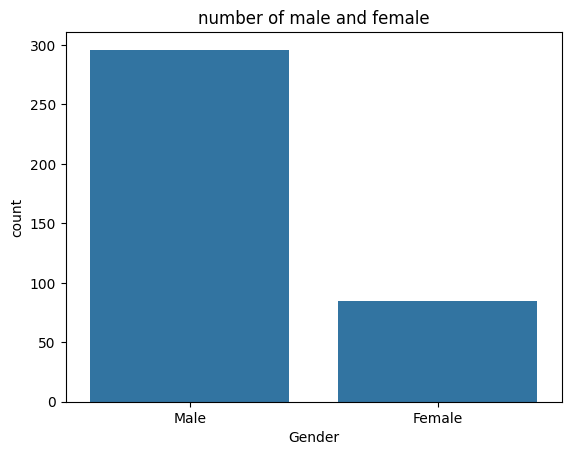

In [60]:
sns.countplot(data=df,x='Gender')
plt.title('number of male and female')

Text(0.5, 1.0, 'Gender vs Loan_Status')

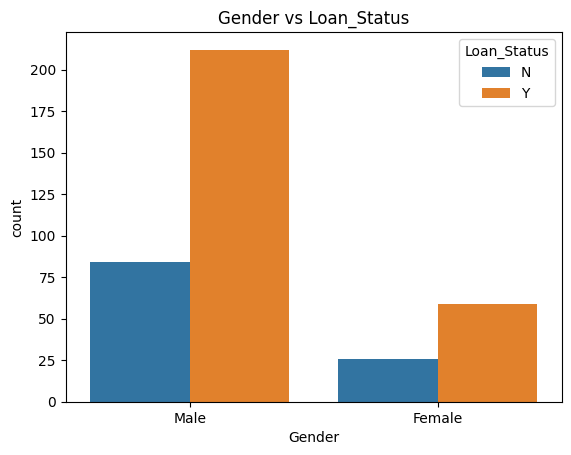

In [61]:
sns.countplot(data=df,x='Gender',hue='Loan_Status')
plt.title('Gender vs Loan_Status')

Text(0.5, 1.0, 'Married vs Loan_Status')

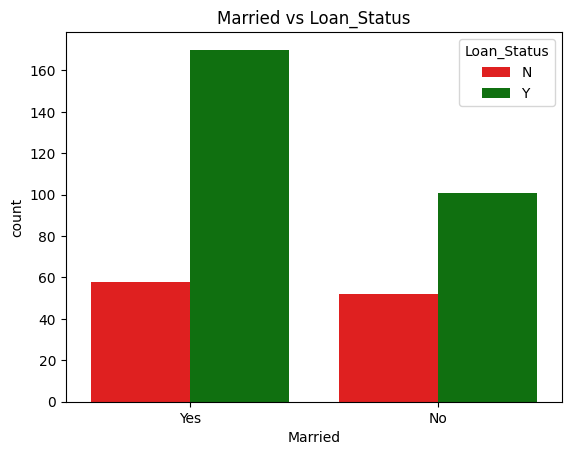

In [69]:
sns.countplot(data=df,x='Married',hue='Loan_Status',palette=['r','g'])
plt.title('Married vs Loan_Status')

Text(0.5, 1.0, 'Property_Area vs Loan_Status')

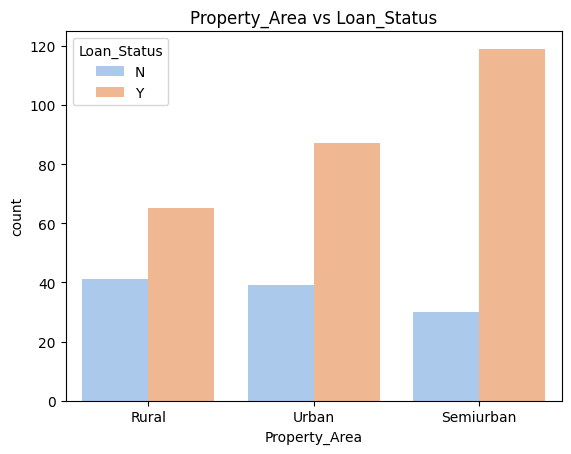

In [75]:
sns.countplot(data=df,x='Property_Area',hue='Loan_Status',palette='pastel')
plt.title('Property_Area vs Loan_Status')

Text(0.5, 1.0, 'Property_Area')

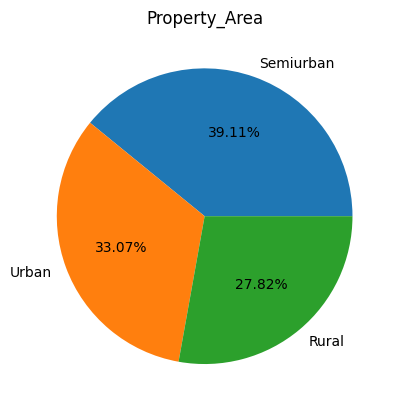

In [80]:
plt.pie(df['Property_Area'].value_counts(),labels=df['Property_Area'].value_counts().index,autopct='%1.2f%%')
plt.title('Property_Area')

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [7]:
df=df.drop('Dependents',axis=1)


In [9]:
x=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [10]:
df.Gender=df.Gender.map({'Male':1,'Female':2})

In [11]:
df.Property_Area=df.Property_Area.map({'Urban':1,'Semiurban':2,'Rural':3})

In [12]:
df.Education=df.Education.map({'Graduate':1,'Not Graduate':2})

In [13]:
df.Married=df.Married.map({'Yes':1,'No':2})

In [14]:
df.Self_Employed=df.Self_Employed.map({'No':0,'Yes':1})

In [18]:
df.Loan_Status=df.Loan_Status.map({'Y':1,'N':2})

In [15]:
df=df.drop('Loan_ID',axis=1)

In [16]:
df.replace({'Loan_Status':{'Y':1,'N':2}})

/tmp/ipykernel_12888/2263986033.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Loan_Status':{'Y':1,'N':2}})


,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,3,2
1,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,1
2,1,1,2,0,2583,2358.0,120.0,360.0,1.0,1,1
3,1,2,1,0,6000,0.0,141.0,360.0,1.0,1,1
4,1,1,2,0,2333,1516.0,95.0,360.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
376,1,1,1,0,5703,0.0,128.0,360.0,1.0,1,1
377,1,1,1,0,3232,1950.0,108.0,360.0,1.0,3,1
378,2,2,1,0,2900,0.0,71.0,360.0,1.0,3,1
379,1,1,1,0,4106,0.0,40.0,180.0,1.0,3,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             381 non-null    int64  
 1   Married            381 non-null    int64  
 2   Education          381 non-null    int64  
 3   Self_Employed      381 non-null    int64  
 4   ApplicantIncome    381 non-null    int64  
 5   CoapplicantIncome  381 non-null    float64
 6   LoanAmount         381 non-null    float64
 7   Loan_Amount_Term   381 non-null    float64
 8   Credit_History     381 non-null    float64
 9   Property_Area      381 non-null    int64  
 10  Loan_Status        381 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 32.9 KB


In [27]:
x=df.drop('Loan_Status',axis=1)
y=df.Loan_Status
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.15,random_state=42)
sv=SVC()
sv.fit(x_train,y_train )
y_pred=sv.predict(x_test)


In [28]:
accuracy_score(y_test,y_pred)


0.7068965517241379

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.7758620689655172